In [1]:
import pandas as pd
import numpy as np

In [2]:
patient_info = pd.read_csv('/home/simon/sshfs_mounts/fermi/Data/Augsburg_large/patient_info.csv', index_col=[0])
results = pd.read_excel('/home/simon/sshfs_mounts/fermi/Data/Augsburg_large/results.xlsx', index_col=[0, 1])

# Data exploration

In [3]:
patient_info.head()

,Age,Sex
Patient,,
PA000291,16.0,F
PA000464,13.0,F
PA000654,13.0,F
PA000926,9.0,M
PA000154,15.0,M


In [4]:
results.head()

CCD (actual)  CCD (projected)   AT (Lee)  AT (Murphy)  \
Patient  Side                                                           
PA000291 right    136.780084       150.458997  11.556465    44.530373   
         left     111.691209       115.309648   7.323683    19.777573   
PA000464 right           NaN              NaN        NaN          NaN   
         left     110.662322       130.854774        NaN    76.443208   
PA000654 right    102.797367        99.197674 -13.766234     0.206099   

                       TT         KRA  
Patient  Side                          
PA000291 right  31.976600  171.068847  
         left   46.061608    4.107275  
PA000464 right  28.586362  168.994233  
         left   45.870811   10.784298  
PA000654 right  33.564101    7.144485

In [5]:
combined = results.join(patient_info)

In [6]:
combined.head()

CCD (actual)  CCD (projected)   AT (Lee)  AT (Murphy)  \
Patient  Side                                                           
PA000291 right    136.780084       150.458997  11.556465    44.530373   
         left     111.691209       115.309648   7.323683    19.777573   
PA000464 right           NaN              NaN        NaN          NaN   
         left     110.662322       130.854774        NaN    76.443208   
PA000654 right    102.797367        99.197674 -13.766234     0.206099   

                       TT         KRA   Age Sex  
Patient  Side                                    
PA000291 right  31.976600  171.068847  16.0   F  
         left   46.061608    4.107275  16.0   F  
PA000464 right  28.586362  168.994233  13.0   F  
         left   45.870811   10.784298  13.0   F  
PA000654 right  33.564101    7.144485  13.0   F

In [7]:
combined.describe()

,CCD (actual),CCD (projected),AT (Lee),AT (Murphy),TT,KRA,Age
count,1777.000000,1777.000000,1655.000000,1782.000000,1599.000000,1603.000000,1902.000000
mean,119.106533,130.364903,6.418613,24.798919,36.118028,37.452514,15.766562
std,19.698203,20.760251,14.214564,19.060851,12.152912,66.577371,7.414402
min,90.054008,90.048083,-31.302095,-51.842773,-86.611614,0.000000,6.000000
25%,102.799025,115.184082,-3.871710,13.213462,29.838278,2.641822,12.000000
50%,116.099873,131.758532,6.001714,24.220157,36.497564,5.859017,14.000000
75%,130.695717,143.623000,16.412161,35.577992,43.179604,11.549356,16.000000
max,175.402983,179.994180,71.176564,172.247667,94.781721,180.000000,64.000000


In [8]:
combined['Sex'].value_counts()

Sex
M    980
F    920
O      2
Name: count, dtype: int64

Remove 'other'...

# Data preprocessing

In [9]:
combined.drop(combined[combined['Sex'] == 'O'].index, inplace=True)

## Outlier removal

In [10]:
def set_outliers_to_nan(column):
    mean = column.mean()
    std = column.std()
    return column.apply(lambda x: np.nan if abs(x - mean) > 2 * std else x)

In [11]:
combined[['CCD (actual)', 'CCD (projected)', 'AT (Lee)', 'AT (Murphy)', 'TT', 'KRA']] = combined[['CCD (actual)', 'CCD (projected)', 'AT (Lee)', 'AT (Murphy)', 'TT', 'KRA']].apply(set_outliers_to_nan)

In [12]:
combined.describe()

,CCD (actual),CCD (projected),AT (Lee),AT (Murphy),TT,KRA,Age
count,1691.000000,1737.000000,1581.000000,1707.000000,1551.000000,1351.000000,1900.000000
mean,116.929723,129.368675,6.038970,24.445193,36.396880,11.798467,15.766316
std,17.535521,19.852274,12.572618,15.202745,9.031831,32.165402,7.418302
min,90.054008,90.048083,-21.628398,-13.307387,12.443340,0.000000,6.000000
25%,102.278315,114.871878,-3.757579,13.694263,30.078805,2.256127,12.000000
50%,114.592249,131.162624,5.837610,24.208268,36.502010,4.672984,14.000000
75%,128.527909,142.726331,15.696980,34.992020,42.961291,8.133219,16.000000
max,158.446307,171.737664,34.542246,62.887554,60.158010,170.630615,64.000000


# AT as function of age

In [13]:
from sklearn import linear_model

In [14]:
X = combined[['AT (Lee)', 'AT (Murphy)', 'Age']].copy()
X = X.dropna()
Y_1 = X['AT (Lee)']
Y_2 = X['AT (Murphy)']
X = X['Age'].to_numpy().reshape(-1, 1)

In [15]:
reg_1 = linear_model.LinearRegression()
reg_1.fit(X, Y_1)
reg_1.coef_

array([-0.02509773])

In [16]:
reg_2 = linear_model.LinearRegression()
reg_2.fit(X, Y_2)
reg_2.coef_

array([0.16394159])

In [17]:
from matplotlib import pyplot as plt

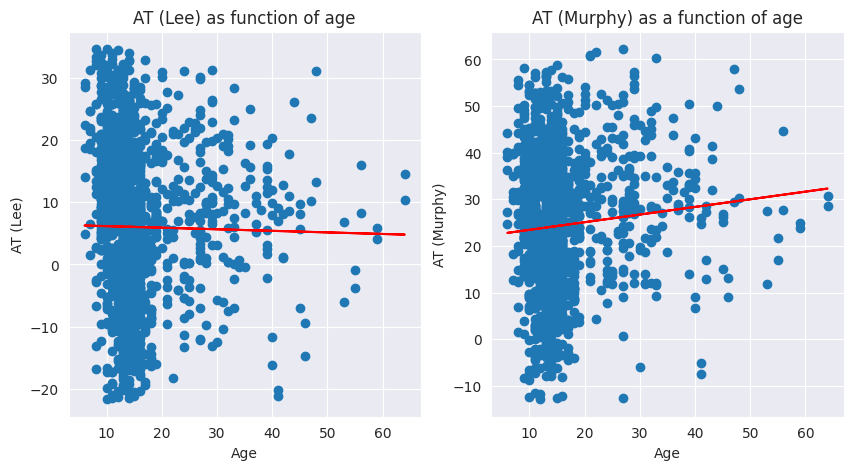

In [18]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=False)
ax[0].scatter(X, Y_1)
ax[0].plot(X, reg_1.predict(X), 'r')
ax[0].set(title='AT (Lee) as function of age', xlabel='Age', ylabel='AT (Lee)')
ax[1].scatter(X, Y_2)
ax[1].plot(X, reg_2.predict(X), 'r')
ax[1].set(title='AT (Murphy) as a function of age', xlabel='Age', ylabel='AT (Murphy)')
plt.show()

# AT as function of sex

In [19]:
data = combined[['AT (Lee)', 'AT (Murphy)', 'Sex']].copy()
data = data.dropna()

In [20]:
import seaborn as sns

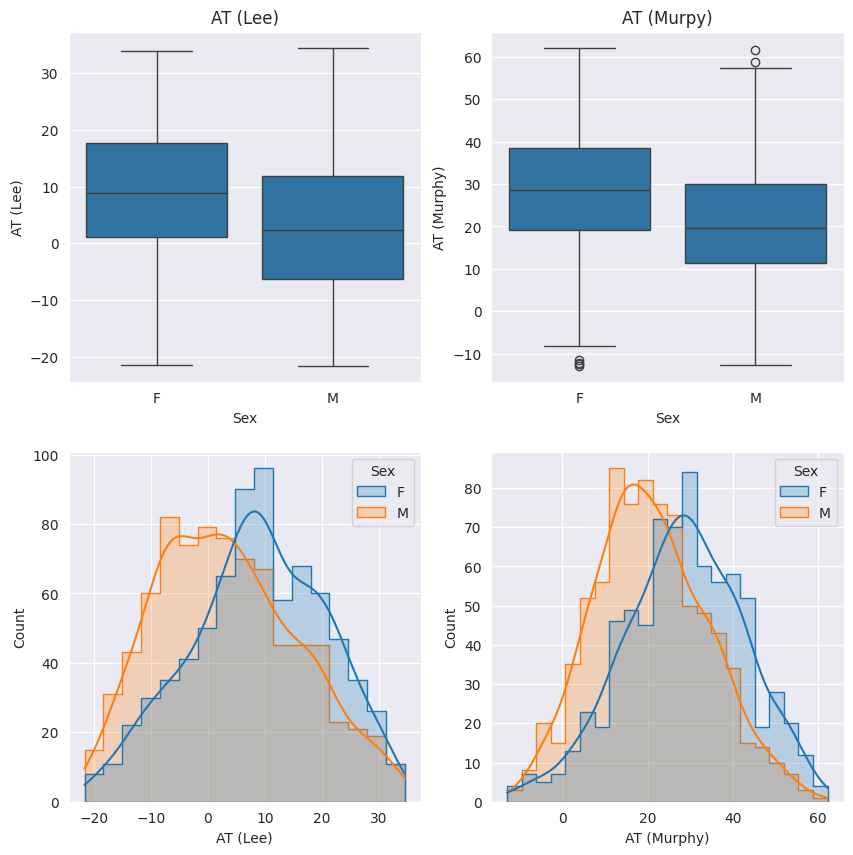

In [21]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
sns.boxplot(x='Sex', y='AT (Lee)', data=data, ax=ax[0, 0])
ax[0][0].set(title='AT (Lee)')
sns.boxplot(x='Sex', y='AT (Murphy)', data=data, ax=ax[0, 1])
ax[0][1].set(title='AT (Murpy)')
sns.histplot(x='AT (Lee)', hue='Sex', kde=True, element='step', data=data, ax=ax[1, 0])
sns.histplot(x='AT (Murphy)', hue='Sex', kde=True, element='step', data=data, ax=ax[1, 1])
plt.show()


In [22]:
from scipy import stats

In [23]:
from sklearn.preprocessing import LabelBinarizer

In [24]:
lb = LabelBinarizer()
lb.fit(data['Sex'])

LabelBinarizer()

In [25]:
labels = lb.transform(data['Sex'])

In [26]:
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 right   F      0
         left    F      0
PA000654 right   F      0
         left    F      0
PA000926 right   M      1
...             ..    ...
PA001031 left    F      0
PA000807 right   F      0
         left    F      0
PA000227 right   M      1
         left    M      1

[1559 rows x 2 columns]

In [27]:
stats.pointbiserialr(labels.T[0], data['AT (Lee)'].to_numpy())  # wtf numpy

SignificanceResult(statistic=-0.21385044273846068, pvalue=1.391095959580247e-17)

In [28]:
stats.pointbiserialr(labels.T[0], data['AT (Murphy)'].to_numpy())  # wtf numpy

SignificanceResult(statistic=-0.26867781193204365, pvalue=3.4727074421105725e-27)

**Interpretation:** Male is encoded 1 and Female is encoded 0, so a negative correlation means that the AT is higher for females

## Normality testing

In [29]:
at_lee_male, at_lee_female = data[data['Sex'] == 'M']['AT (Lee)'], data[data['Sex'] == 'F']['AT (Lee)']
at_murphy_male, at_murphy_female = data[data['Sex'] == 'M']['AT (Murphy)'], data[data['Sex'] == 'F']['AT (Murphy)']

In [30]:
stats.shapiro(at_lee_male.to_numpy())

ShapiroResult(statistic=0.9821299159573953, pvalue=2.3372498413085427e-08)

In [31]:
stats.shapiro(at_lee_female.to_numpy())

ShapiroResult(statistic=0.9895791299898452, pvalue=3.497640022498309e-05)

In [32]:
stats.shapiro(at_murphy_male.to_numpy())

ShapiroResult(statistic=0.9939396082162768, pvalue=0.002483046162338597)

In [33]:
stats.shapiro(at_murphy_female.to_numpy())

ShapiroResult(statistic=0.9946699607347214, pvalue=0.009755021078026003)

**These results are contradictory (?), check q-q plots:**

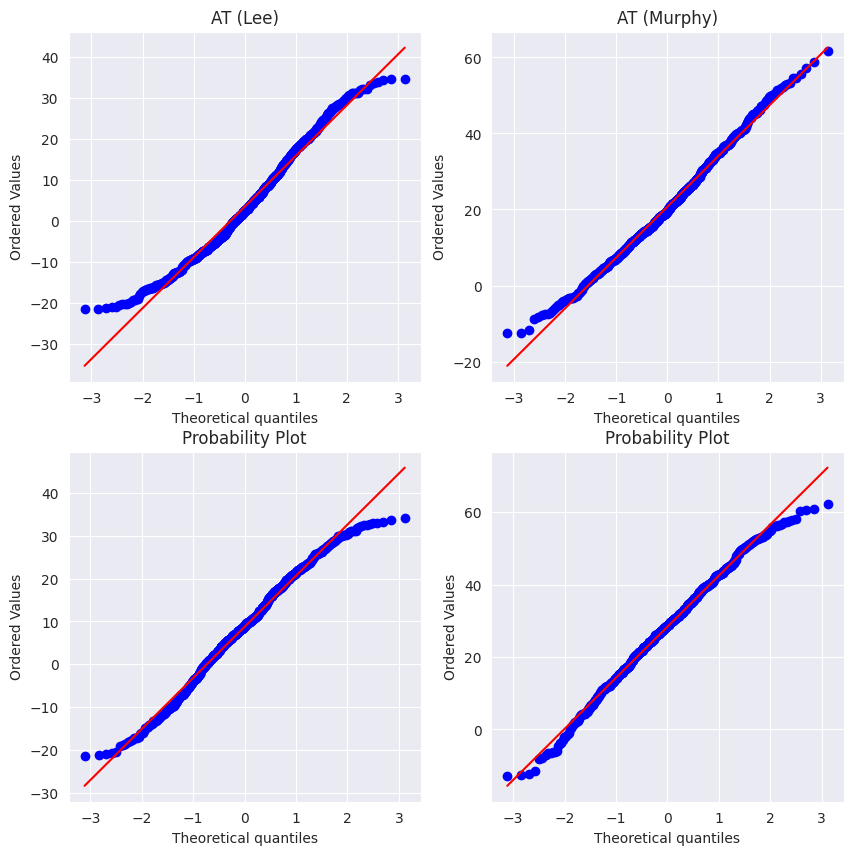

In [34]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
stats.probplot(at_lee_male.to_numpy(), plot=ax[0, 0])
ax[0, 0].set(title='AT (Lee)')
stats.probplot(at_lee_female.to_numpy(), plot=ax[1, 0])
stats.probplot(at_murphy_male.to_numpy(), plot=ax[0, 1])
ax[0, 1].set(title='AT (Murphy)')
stats.probplot(at_murphy_female.to_numpy(), plot=ax[1, 1])
plt.show()

**Plots show data are normally distributed**

In [35]:
stats.levene(at_lee_male, at_lee_female)

LeveneResult(statistic=2.4959449179543673, pvalue=0.11434296836538142)

In [36]:
stats.levene(at_murphy_male, at_murphy_female)

LeveneResult(statistic=1.3657631478217247, pvalue=0.24272006680327254)

**Can assume both to have equal variance**

In [37]:
stats.ttest_ind(at_lee_male.to_numpy(), at_lee_female.to_numpy(), equal_var=True)

TtestResult(statistic=-8.63812098363991, pvalue=1.3910959595802353e-17, df=1557.0)

In [38]:
stats.ttest_ind(at_murphy_male.to_numpy(), at_murphy_female.to_numpy(), equal_var=True)

TtestResult(statistic=-11.0064195081783, pvalue=3.472707442110766e-27, df=1557.0)

**-> There is a significant difference between male and female**

## Effect size

In [39]:
import numpy as np

In [40]:
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

In [41]:
cohen_d(at_lee_male.to_numpy(), at_lee_female.to_numpy())

-0.4378015864533291

In [42]:
cohen_d(at_murphy_male.to_numpy(), at_murphy_female.to_numpy())

-0.5578328818243605

**Interpretation:**
- 0.2 < d < 0.5: small effect
- 0.5 < d < 0.8: medium effect
- 0.8 < d: strong effect

# TT as function of age

In [43]:
X = combined[['TT', 'Age']].copy()
X = X.dropna()
Y = X['TT']
X = X['Age'].to_numpy().reshape(-1, 1)

In [44]:
reg = linear_model.LinearRegression()
reg.fit(X, Y)
reg.coef_

array([-0.05717308])

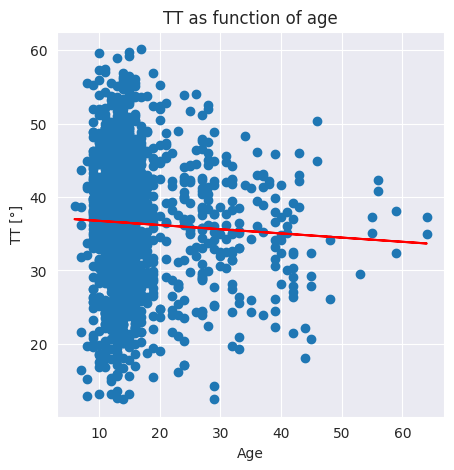

In [45]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X, Y)
ax.plot(X, reg.predict(X), 'r')
ax.set(title='TT as function of age', xlabel='Age', ylabel='TT [°]')
plt.show()

# TT as function of sex

In [46]:
data = combined[['TT', 'Sex']].copy()
data = data.dropna()

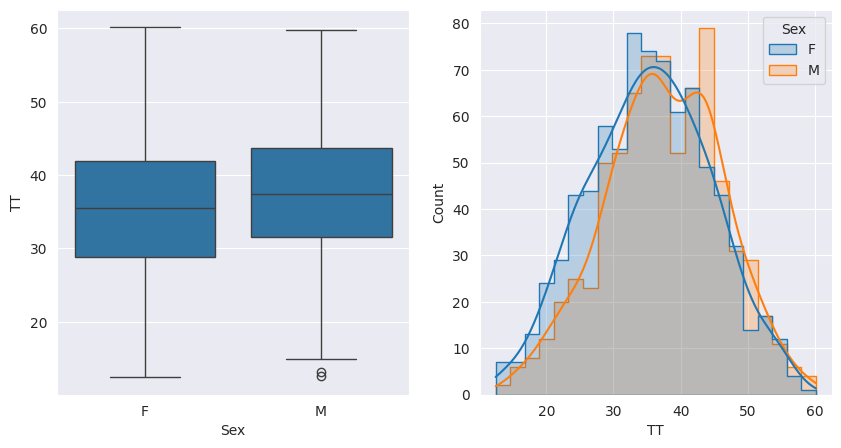

In [47]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
sns.boxplot(x='Sex', y='TT', data=data, ax=ax[0])
sns.histplot(x='TT', hue='Sex', kde=True, element='step', data=data, ax=ax[1])
plt.show()

In [48]:
lb = LabelBinarizer()
lb.fit(data['Sex'])
labels = lb.transform(data['Sex'])

In [49]:
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 right   F      0
         left    F      0
PA000464 right   F      0
         left    F      0
PA000654 right   F      0
...             ..    ...
PA001031 left    F      0
PA000807 right   F      0
         left    F      0
PA000227 right   M      1
         left    M      1

[1551 rows x 2 columns]

In [50]:
stats.pointbiserialr(labels.T[0], data['TT'].to_numpy())  # wtf numpy

SignificanceResult(statistic=0.11490149857363252, pvalue=5.719025922511762e-06)

**Interpretation:** Positive coefficient means TT is higher for males (encoded as 1)

## Normality testing

In [51]:
tt_male, tt_female = data[data['Sex'] == 'M']['TT'], data[data['Sex'] == 'F']['TT']

In [52]:
stats.shapiro(tt_male.to_numpy())

ShapiroResult(statistic=0.9959894415063324, pvalue=0.051507888109421286)

In [53]:
stats.shapiro(tt_female.to_numpy())

ShapiroResult(statistic=0.9959132788830363, pvalue=0.03379242016828322)

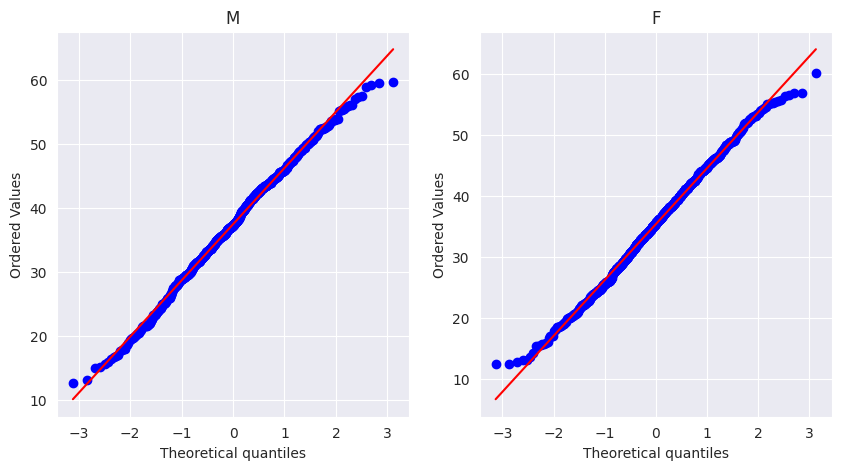

In [54]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
stats.probplot(tt_male.to_numpy(), plot=ax[0])
ax[0].set(title='M')
stats.probplot(tt_female.to_numpy(), plot=ax[1])
ax[1].set(title='F')
plt.show()

**Plots show data are normally distributed**

In [55]:
stats.levene(tt_male, at_lee_female)

LeveneResult(statistic=62.435562465009134, pvalue=5.284357589498211e-15)

In [56]:
stats.levene(tt_female, at_murphy_female)

LeveneResult(statistic=111.49953290509016, pvalue=3.2200493870097425e-25)

**Can assume both to not have equal variance**

In [57]:
stats.ttest_ind(tt_male.to_numpy(), tt_female.to_numpy(), equal_var=False)

TtestResult(statistic=4.5584742622576115, pvalue=5.557671031009658e-06, df=1548.027069770721)

**-> There is a significant difference between male and female**

## Effect size

In [58]:
cohen_d(tt_male.to_numpy(), tt_female.to_numpy())

0.23131103860364877

**Interpretation:**
- 0.2 < d < 0.5: small
effect
- 0.5 < d < 0.8: medium
effect
- 0.8 < d: strong
effect

# CCD as function of age

In [59]:
X = combined[['CCD (actual)', 'CCD (projected)', 'Age']].copy()
X = X.dropna()
Y_1 = X['CCD (actual)']
Y_2 = X['CCD (projected)']
X = X['Age'].to_numpy().reshape(-1, 1)

In [60]:
reg_1 = linear_model.LinearRegression()
reg_1.fit(X, Y_1)
reg_1.coef_

array([0.26045171])

In [61]:
stats.pearsonr(X.flatten(), Y_1)

PearsonRResult(statistic=0.11179143322094134, pvalue=4.756595253471878e-06)

In [62]:
reg_2 = linear_model.LinearRegression()
reg_2.fit(X, Y_2)
reg_2.coef_

array([0.03437839])

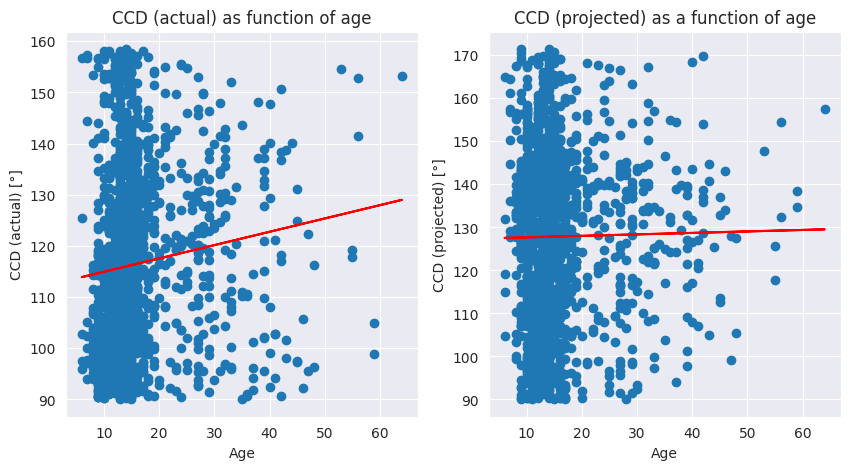

In [63]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=False)
ax[0].scatter(X, Y_1)
ax[0].plot(X, reg_1.predict(X), 'r')
ax[0].set(title='CCD (actual) as function of age', xlabel='Age', ylabel='CCD (actual) [°]')
ax[1].scatter(X, Y_2)
ax[1].plot(X, reg_2.predict(X), 'r')
ax[1].set(title='CCD (projected) as a function of age', xlabel='Age', ylabel='CCD (projected) [°]')
plt.show()

# CCD as function of Sex

In [64]:
data = combined[['CCD (actual)', 'CCD (projected)', 'Sex']].copy()
data = data.dropna()

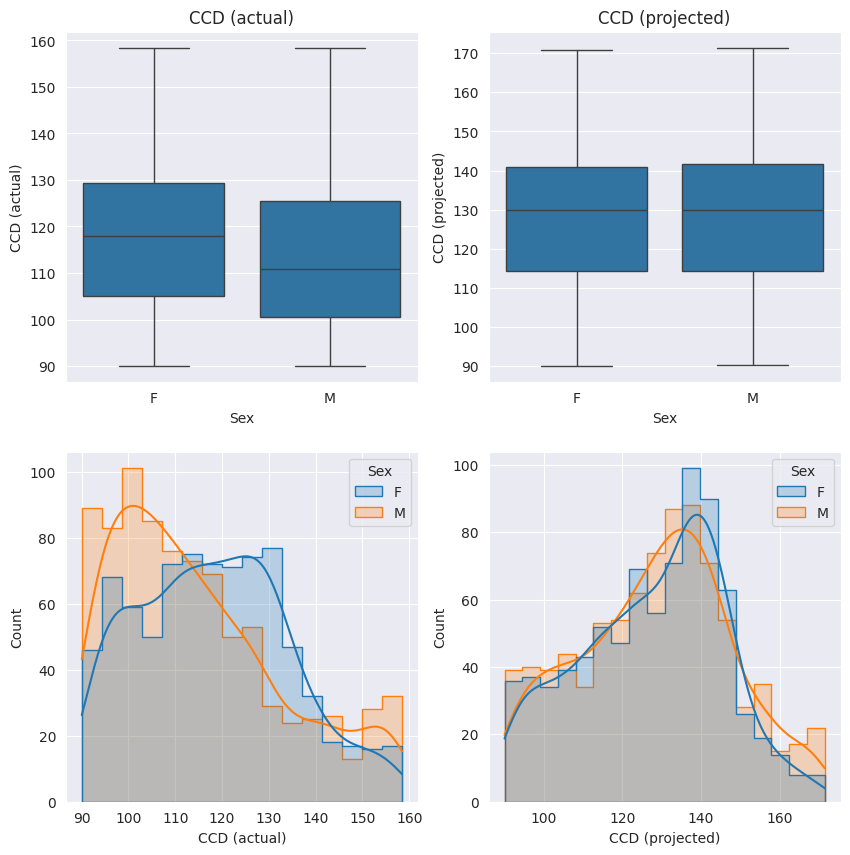

In [65]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
sns.boxplot(x='Sex', y='CCD (actual)', data=data, ax=ax[0, 0])
ax[0][0].set(title='CCD (actual)')
sns.boxplot(x='Sex', y='CCD (projected)', data=data, ax=ax[0, 1])
ax[0][1].set(title='CCD (projected)')
sns.histplot(x='CCD (actual)', hue='Sex', kde=True, element='step', data=data, ax=ax[1, 0])
sns.histplot(x='CCD (projected)', hue='Sex', kde=True, element='step', data=data, ax=ax[1, 1])
plt.show()

In [66]:
lb = LabelBinarizer()
lb.fit(data['Sex'])
labels = lb.transform(data['Sex'])

In [67]:
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 right   F      0
         left    F      0
PA000464 left    F      0
PA000654 right   F      0
         left    F      0
...             ..    ...
PA001031 left    F      0
PA000807 right   F      0
         left    F      0
PA000227 right   M      1
         left    M      1

[1667 rows x 2 columns]

In [68]:
stats.pointbiserialr(labels.T[0], data['CCD (actual)'].to_numpy())  # wtf numpy

SignificanceResult(statistic=-0.09926051253687584, pvalue=4.913838121951878e-05)

**Interpretation:** Negative coefficient means CCD is higher for females (encoded as 0)

In [69]:
stats.pointbiserialr(labels.T[0], data['CCD (projected)'].to_numpy())  # wtf numpy

SignificanceResult(statistic=0.021331053752467875, pvalue=0.38409854169688534)

**Interpretation:** Positive coefficient means CCD is higher for males (encoded as 1)

## Normality testing

In [70]:
ccd_actual_male, ccd_actual_female = data[data['Sex'] == 'M']['CCD (actual)'], data[data['Sex'] == 'F']['CCD (actual)']
ccd_projected_male, ccd_projected_female = data[data['Sex'] == 'M']['CCD (projected)'], data[data['Sex'] == 'F']['CCD (projected)']

In [71]:
stats.shapiro(ccd_actual_male.to_numpy())

ShapiroResult(statistic=0.9256309719387638, pvalue=3.746240913570797e-20)

In [72]:
stats.shapiro(ccd_actual_female.to_numpy())

ShapiroResult(statistic=0.9774305976611203, pvalue=7.168300457397769e-10)

In [73]:
stats.shapiro(ccd_projected_male.to_numpy())

ShapiroResult(statistic=0.9831258447493052, pvalue=2.2422273942900892e-08)

In [74]:
stats.shapiro(ccd_projected_female.to_numpy())

ShapiroResult(statistic=0.976520390844183, pvalue=3.9055747581136364e-10)

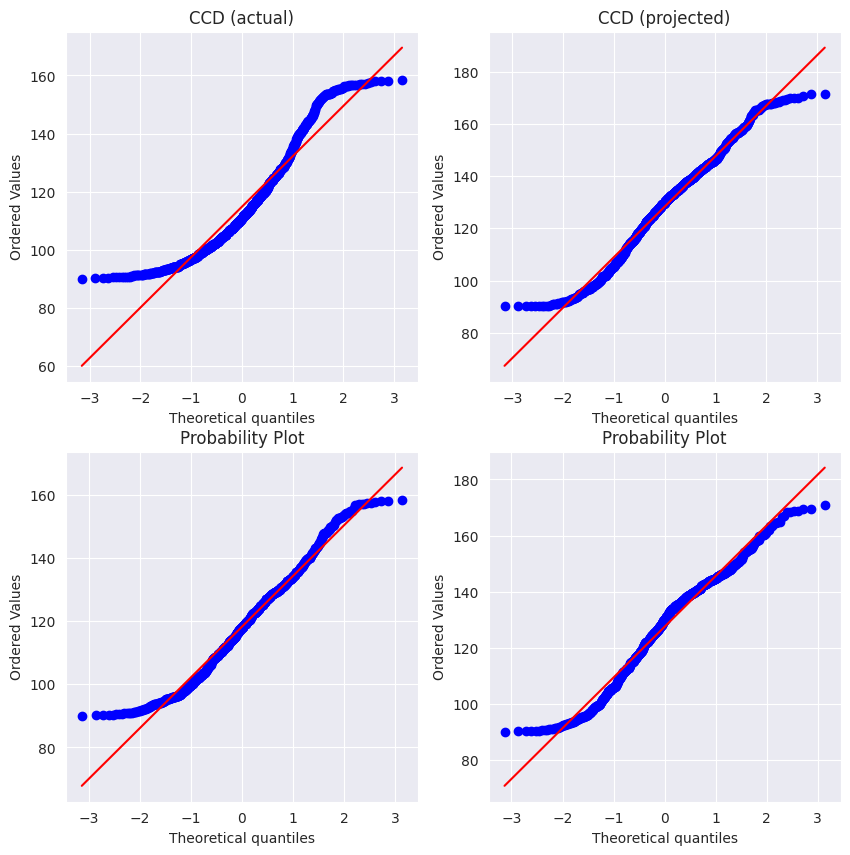

In [75]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
stats.probplot(ccd_actual_male.to_numpy(), plot=ax[0, 0])
ax[0, 0].set(title='CCD (actual)')
stats.probplot(ccd_actual_female.to_numpy(), plot=ax[1, 0])
stats.probplot(ccd_projected_male.to_numpy(), plot=ax[0, 1])
ax[0, 1].set(title='CCD (projected)')
stats.probplot(ccd_projected_female.to_numpy(), plot=ax[1, 1])
plt.show()

**Plots show data are not normally distributed**

In [76]:
stats.mannwhitneyu(ccd_actual_male, ccd_actual_female, alternative='two-sided')

MannwhitneyuResult(statistic=295407.0, pvalue=1.4166131809580216e-07)

In [77]:
stats.mannwhitneyu(ccd_projected_male, ccd_projected_female, alternative='two-sided')

MannwhitneyuResult(statistic=351478.0, pvalue=0.6564552225233862)

**There is only a significant difference for the actual CCD**

## Effect size

In [78]:
%load_ext rpy2.ipython

In [91]:
len(ccd_actual_male), len(ccd_actual_female)

(856, 811)

In [89]:
%%R
library(effectsize)

In [97]:
tmp1, tmp2 = ccd_actual_male.to_numpy(), ccd_actual_female.to_numpy()

In [100]:
%%R -i tmp1 -i tmp2
ccd_actual_male <- tmp1
ccd_actual_female <- tmp2

  [1] 134.55810 104.53391 143.19270 105.65472  92.27574 109.51136 112.44741
  [8]  97.11238 106.27776 153.02495 155.53327 148.59288 111.02350 108.55988
 [15] 143.96967 131.76947 122.27902 121.30249  99.09371 111.60358 124.22327
 [22]  97.64062 153.74768  96.73380 111.33368 136.85409 152.55511 123.63293
 [29] 126.54772 108.41854 117.44440 104.63127 150.07489 129.68927 142.06586
 [36] 113.20256 139.87219 107.29312 112.58247 104.28211 111.66952 110.83458
 [43] 122.82846 134.37398  98.95565 109.91735 151.52451 153.84073  99.59864
 [50] 119.23077  95.27569 147.12489  97.98166 110.92452 110.29930  97.88839
 [57] 106.89894 128.38435 108.56116 118.50598 131.58598 115.96902  94.12895
 [64] 116.28291 117.44581 120.08293  96.76458 125.61859  95.71489 106.75542
 [71]  97.27721 128.54010  92.35479 113.26183  95.23562 103.63092 153.88755
 [78] 134.06680  92.54688 104.11198 112.72301 104.34571 101.47391 155.45009
 [85]  99.81367 113.25111  99.79837 118.52715 129.16609 138.05855 105.00206
 [92] 116.73

In [105]:
%%R
rb <- rank_biserial(ccd_actual_male, ccd_actual_female)
print(interpret(rb, rules='funder2019'))

r (rank biserial) |         95% CI | Interpretation
---------------------------------------------------
-0.15             | [-0.20, -0.09] |          small

- Interpretation rule: funder2019

In [106]:
tmp1, tmp2 = ccd_projected_male.to_numpy(), ccd_projected_female.to_numpy()

In [107]:
%%R -i tmp1 -i tmp2
ccd_projected_male <- tmp1
ccd_projected_female <- tmp2


In [108]:
%%R
rb <- rank_biserial(ccd_projected_male, ccd_projected_female)
print(interpret(rb, rules='funder2019'))

r (rank biserial) |        95% CI | Interpretation
--------------------------------------------------
0.01              | [-0.04, 0.07] |           tiny

- Interpretation rule: funder2019